In [47]:
# KI mit Python: Ein einfaches 2-Schichten-Perzeptron-Netzwerk zur Linienerkennung implementieren und trainieren
# GT mit Unterstützung von Gemini Pro 3.1 (April 2026)

# Programmbibliotheken importieren
import numpy as np
import matplotlib.pyplot as plt
import copy
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
from IPython.display import display, clear_output


In [51]:
# 1. Trainingsdaten erzeugen
# 1.1 Positive Beispiele: Linien auf einem 4x4 Raster

# Indexe der Linien in einem 4x4 Raster definieren
horizontal_lines = [[0,1,2,3], [4,5,6,7],[8,9,10,11], [12,13,14,15]]
vertical_lines   = [[0,4,8,12],[1,5,9,13], [2,6,10,14], [3,7,11,15]]
# Diagonalen  von oben links nach unten rechts und von oben rechts nach unten links ohne Eckpunkte
diagonal_1 = [[0,5,10,15],[1,6,11], [4,9,14], [2,7], [8,13]] # Top-left to bottom-right
diagonal_2 = [[3,6,9,12], [2,5,8],[7,10,13], [1,4], [11,14]] # Top-right to bottom-left
all_line_indices = horizontal_lines + vertical_lines + diagonal_1 + diagonal_2

# Positive Daten mit Labeln erzeugen (Linien auf 4x4 Raster)
X_true =[]
for indices in all_line_indices:
    # Schwarze Linie auf weißem Hintergrund (1 auf 0)
    grid_black = np.zeros(16)
    grid_black[indices] = 1
    X_true.append(grid_black)
    
    # Weiße Linie auf schwarzem Hintergrund (0 auf 1)
    grid_white = np.ones(16)
    grid_white[indices] = 0
    X_true.append(grid_white)

X_true = np.array(X_true)
y_true = np.ones((len(X_true), 1)) # Label "1" bedeutet "wahr" d.h. "Linie vorhanden"


In [52]:
# 1.2 Negative Beispiele (Zufällige Muster ohne Linien)

np.random.seed(42) # For reproducible results
X_false =[]
while len(X_false) < 150: # Genug negative Beispiele generieren
    random_grid = np.random.randint(0, 2, 16)
    # Zufällig erzeugte Linien aussortieren
    if not any(np.array_equal(random_grid, t) for t in X_true):
        X_false.append(random_grid)
        
X_false = np.array(X_false)
y_false = np.zeros((len(X_false), 1)) # Label "0" means False / No Line

# 1.3 Kombinieren und durchmischen der positiven und negativen Beispiele
X = np.vstack((X_true, X_false))
y = np.vstack((y_true, y_false))


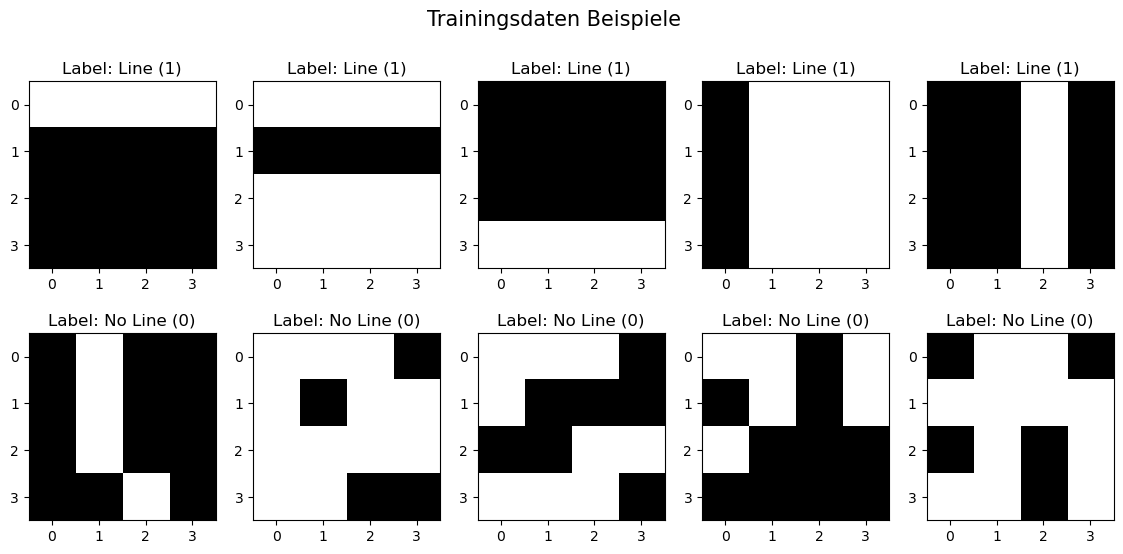

In [53]:

# 1.4 Trainingsdaten visualisieren

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Trainingsdaten Beispiele", fontsize=15)
for i in range(5):
    # Top row: True lines
    axes[0, i].imshow(X_true[i*3].reshape(4,4), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title("Label: Line (1)")
    axes[0, i].axis('on')
    
    # Bottom row: False (Random)
    axes[1, i].imshow(X_false[i].reshape(4,4), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title("Label: No Line (0)")
    axes[1, i].axis('on')
plt.show()

In [60]:
# 2. Definition des Neuronalen Netzwerks

# 2.1 Die Aktivierungsfunktion im Knoten (Sigmoid-Aktivierung, damit die Werte zwischen 0 und 1 liegen)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2.2 Ableitung der Sigmoid-Funktion für die "Backpropagation"
def sigmoid_derivative(x):
    return x * (1 - x) # Das ist die Formel für die Fallinien der Sigmoid-Funktion für "Gradientenabstieg"

# 2.3 Eine Python-Klasse für das Neuronale Netzwerk erstellen

class LineDetectorNetworkViz:
    # 16 Inputs (pixels) -> 12 "hidden neurons" -> output (Yes/No)
    # Die Gewichte der Verbindungen zwischen den Schichten werden mit Zufallszahlen initialisiert
    def __init__(self):
        # Gewichte und Bias für die Ausgabe-Schicht
        self.weights_hidden = np.random.uniform(-1, 1, (16, 12))
        self.bias_hidden = np.zeros((1, 12))
        
        self.weights_output = np.random.uniform(-1, 1, (12, 1))
        self.bias_output = np.zeros((1, 1))
        # Lernrate für die Gewichtsanpassung
        self.learning_rate = 0.05
        self.history =[] # <--- NEW: List to store snapshots over time
    
    # 2.3.1 Vorwärtsdurchlauf (Forward Pass) durch das Netzwerk
    def predict(self, inputs):
        self.hidden_layer = sigmoid(np.dot(inputs, self.weights_hidden) + self.bias_hidden)
        self.output_layer = sigmoid(np.dot(self.hidden_layer, self.weights_output) + self.bias_output)
        return self.output_layer
    
    # 2.3.2 Trainingsalgorithmus (Training Algorithm)
    def train(self, inputs, expected_outputs, epochs):
           # Vorwärtsdurchlauf: Berechnung der Ausgabe für die gegebenen Inputs
        for epoch in range(epochs):
            output = self.predict(inputs)
            error = expected_outputs - output
            
            # Schnappschuss der aktuellen Gewichte und Fehler alle 50 Epochen speichern
            if epoch % 50 == 0 or epoch == epochs - 1:
                self.history.append({
                    'epoch': epoch,
                    'error': np.mean(np.abs(error)),
                    'w_h': copy.deepcopy(self.weights_hidden),
                    'b_h': copy.deepcopy(self.bias_hidden),
                    'w_o': copy.deepcopy(self.weights_output),
                    'b_o': copy.deepcopy(self.bias_output)
                })
            
            # Backpropagation
            d_output = error * sigmoid_derivative(output)
            error_hidden = d_output.dot(self.weights_output.T)
            d_hidden = error_hidden * sigmoid_derivative(self.hidden_layer)
            
            # Gewichte aktualisieren
            self.weights_output += self.hidden_layer.T.dot(d_output) * self.learning_rate
            self.bias_output += np.sum(d_output, axis=0, keepdims=True) * self.learning_rate
            self.weights_hidden += inputs.T.dot(d_hidden) * self.learning_rate
            self.bias_hidden += np.sum(d_hidden, axis=0, keepdims=True) * self.learning_rate





    
            
      


In [61]:
# 3. Netzwerk trainieren
nn = LineDetectorNetworkViz()
print("Training hat begonnen... speichere die Trainingshistorie.")
nn.train(X, y, epochs=3000)
print(f"Training beendet! Historie in Snapshots gespreichert {len(nn.history)}.")




Training hat begonnen... speichere die Trainingshistorie.
Training beendet! Historie in Snapshots gespreichert 61.


In [ ]:
# Visualisierung des Netzwerks mit Daten von Gewichten und Bias

def visualize_network_state(snapshot_index):
    # Daten aus den Snapshots der Lernhistorie abrufen
    state = nn.history[snapshot_index]
    epoch = state['epoch']
    error = state['error']
    w_h = state['w_h']
    b_h = state['b_h'][0]
    w_o = state['w_o']
    b_o = state['b_o'][0][0]
    
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.axis('off')
    ax.set_xlim(-0.2, 2.5)
    ax.set_ylim(-0.05, 1.05)
    
    # Definition der vertikalen Positionen für die Knoten
    y_in = np.linspace(1, 0, 16)
    y_hid = np.linspace(0.9, 0.1, 12)
    y_out = 0.5
    
    # Zeichnen des Input
    for i in range(16):
        for j in range(12):
            weight = w_h[i, j]
            color = '#1f77b4' if weight > 0 else '#d62728' # Blue (+), Red (-)
            # Stärkere Gewichte weights bedeuten dickere und opakere Linien
            alpha = max(0.1, min(1.0, abs(weight) * 0.4)) 
            linewidth = abs(weight) * 0.8
            ax.plot([0, 1],[y_in[i], y_hid[j]], color=color, alpha=alpha, linewidth=linewidth, zorder=1)
            
    # 2. Draw Hidden -> Output Connections (With exact Text labels!)
    for j in range(12):
        weight = w_o[j, 0]
        color = '#1f77b4' if weight > 0 else '#d62728'
        linewidth = abs(weight) * 1.0
        ax.plot([1, 2], [y_hid[j], y_out], color=color, alpha=0.8, linewidth=linewidth, zorder=1)
        
        # Add a text label halfway down the line
        ax.text(1.5, (y_hid[j] + y_out)/2, f'{weight:+.2f}', color=color, 
                fontsize=9, fontweight='bold', ha='center', va='center',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1), zorder=3)
        
    # 3. Draw Nodes and Biases
    # Input Nodes
    for i, y in enumerate(y_in):
        ax.plot(0, y, marker='o', markersize=14, color='gray', zorder=2)
        ax.text(-0.05, y, f'Pixel {i}', ha='right', va='center', fontsize=10)
        
    # Hidden Nodes + Biases written inside them
    for j, y in enumerate(y_hid):
        ax.plot(1, y, marker='o', markersize=24, color='purple', zorder=2)
        ax.text(1, y, f'{b_h[j]:+.1f}', color='white', fontsize=8, fontweight='bold', ha='center', va='center', zorder=3)
        
    # Output Node + Bias written inside it
    ax.plot(2, y_out, marker='o', markersize=35, color='green', zorder=2)
    ax.text(2, y_out, f'{b_o:+.1f}', color='white', fontsize=10, fontweight='bold', ha='center', va='center', zorder=3)
    ax.text(2.1, y_out, 'Output\n(Line?)', ha='left', va='center', fontsize=14, fontweight='bold')
    
    # Titles and Legends
    plt.title(f"Network Evolution - Epoch: {epoch} | Overall Error Rate: {error:.4f}", fontsize=18, pad=20)
    plt.figtext(0.5, 0.05, "Blue Lines = Positive Weight | Red Lines = Negative Weight | Numbers inside circles = Bias", 
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.show()

# Create the Slider Widget
slider = IntSlider(min=0, max=len(nn.history)-1, step=1, value=0, 
                   description='Time (Slider):', layout={'width': '800px'})

print("🎚️ Drag the slider below to watch the network learn over time!")
interact(visualize_network_state, snapshot_index=slider);

🎚️ Drag the slider below to watch the network learn over time!


interactive(children=(IntSlider(value=0, description='Time (Slider):', layout=Layout(width='800px'), max=60), …

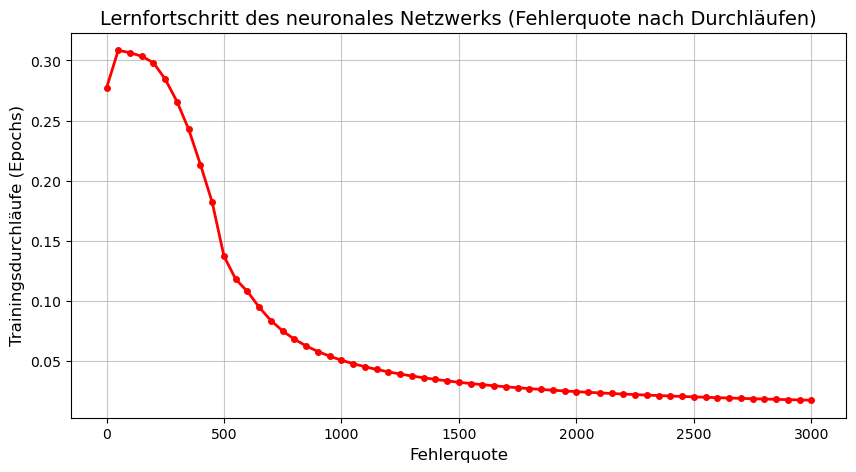

In [63]:


# Darstellen des Lernfortschritts als Diagramm

# Epochen und Daten aus der Historie extrahieren
epochs_recorded = [snapshot['epoch'] for snapshot in nn.history]
errors_recorded = [snapshot['error'] for snapshot in nn.history]

# Daten plotten
plt.figure(figsize=(10, 5))
plt.plot(epochs_recorded, errors_recorded, color='red', linewidth=2, marker='o', markersize=4)

# Labels und Titel
plt.title("Lernfortschritt des neuronales Netzwerks (Fehlerquote nach Durchläufen)", fontsize=14)
plt.xlabel("Fehlerquote", fontsize=12)
plt.ylabel("Trainingsdurchläufe (Epochs)", fontsize=12)
plt.grid(True, linestyle='-', alpha=0.7)
plt.show()


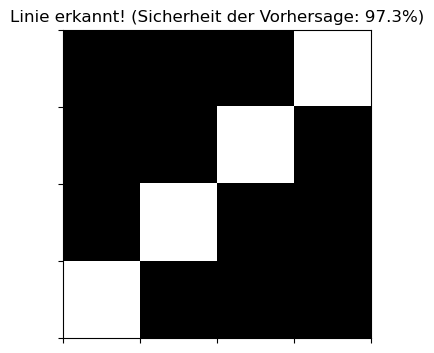

In [65]:
# 4. Testen des Netzwerks mit eigenen Bildern

def test_custom_image(vector_of_16_numbers):
    if len(vector_of_16_numbers) != 16:
        print("Error: Please provide exactly 16 numbers!")
        return
        
    input_array = np.array(vector_of_16_numbers)
    
    # Vorhersage treffen
    prediction_score = nn.predict(input_array)[0][0]
    is_line = prediction_score > 0.5
    
    # Visualisierung des Eingabebildes
    plt.figure(figsize=(4, 4))
    plt.imshow(input_array.reshape(4,4), cmap='gray', vmin=0, vmax=1)
    
    # Formatierung der Antwortausgabe
    if is_line:
        plt.title(f"Linie erkannt! (Sicherheit der Vorhersage: {prediction_score*100:.1f}%)", color='black')
    else:
        plt.title(f"Keine Linie. (Sicherheit der Vorhersage: {(1-prediction_score)*100:.1f}%)", color='black')
        
    # Draw gridlines to make the 4x4 distinct
    plt.xticks(np.arange(-.5, 4, 1),[])
    plt.yticks(np.arange(-.5, 4, 1),[])
    plt.axis('on')
    # plt.grid(color='gray', linestyle='-', linewidth=1)
    plt.show()

# --- Eingabe der Zahlenwerte von Hand ---
# Hier kann man ein eigenes Bild eingeben! (0 is Schwarz, 1 is Weiß)
my_image =[
    0, 0, 0, 1,
    0, 0, 1, 0,
    0, 1, 0, 0,
    1, 0, 0, 0
]

test_custom_image(my_image)

In [66]:
# Erzeuge 16 klickbare Toggle-Buttons, um ein eigenes 4x4 Bild zu zeichnen

buttons =[]
for i in range(16):
    btn = widgets.ToggleButton(value=False, description='0', layout=widgets.Layout(width='100px', height='100px'))
    
    # Farbänderung bei Klick
    def on_click(change, b=btn):
        b.description = '1' if change['new'] else '0'
        b.style.button_color = 'lightgray' if change['new'] else 'white'
        
    btn.observe(on_click, 'value')
    btn.style.button_color = 'white'
    buttons.append(btn)

# Anordnung der Buttons in einem 4x4 Raster
grid = widgets.GridBox(buttons, layout=widgets.Layout(grid_template_columns="repeat(4, 100px)"))

# Ausgabe der Buttons als Eingabe ans Netzwerk
check_btn = widgets.Button(description="Netzwerk anwerfen!", button_style='info', layout=widgets.Layout(width='240px'))
output_area = widgets.Output()

def evaluate_grid(b):
    with output_area:
        clear_output()
        # Den Zustand der Knöfe einlesen
        user_input = np.array([1 if btn.value else 0 for btn in buttons])
        prediction = nn.predict(user_input)[0][0]
        
        print(f"Netzwerk-Rohausgabe: {prediction:.4f}")
        if prediction > 0.5:
            print("Einschätzung: Ja, das ist eine Linie!")
        else:
            print("Einschätzung: Irgendetwas anderes, aber keine Linie")

check_btn.on_click(evaluate_grid)

print("Klicke auf die Kästchen unten, um eine Linie zu zeichnen, dann frage die KI ob das Bild eine Linie darstellt:")
display(grid, check_btn, output_area)

Klicke auf die Kästchen unten, um eine Linie zu zeichnen, dann frage die KI ob das Bild eine Linie darstellt:


GridBox(children=(ToggleButton(value=False, description='0', layout=Layout(height='100px', width='100px')), To…

Button(button_style='info', description='Netzwerk anwerfen!', layout=Layout(width='240px'), style=ButtonStyle(…

Output()